In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('./obesity_data.csv')
data.head()

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese
2,46,Female,168.072202,72.930629,25.817737,4,Overweight
3,32,Male,168.459633,84.886912,29.912247,3,Overweight
4,60,Male,183.568568,69.038945,20.487903,3,Normal weight


In [3]:
# data.size
data.shape

(1000, 7)

#### random sampling technique -- select random data

In [4]:
# 1. Simple random sampling with n rows
random_sample_n = data.sample(n=100,random_state=1)
print('1. Random sample with n=100 rows:\n', random_sample_n.head(), '\n')

# 2. Random sampling with percentage of data
random_sample_frac = data.sample(frac=0.3)  # 30% of data
print('2. Random sample with 30% of data:\n', random_sample_frac.head(), '\n')

# 3. Random sampling with replacement (allows duplicate rows)
random_sample_replace = data.sample(n=100, replace=True)
print('3. Random sample with replacement:\n', random_sample_replace.head(), '\n')

# 4. Random sampling with weights (probability weights for each row)
weighted_sample = data.sample(n=100, weights=data['BMI'])
print('4. Random sample weighted by BMI:\n', weighted_sample.head())

1. Random sample with n=100 rows:
      Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
507   34  Female  145.314571  87.116991  41.255755                      2   
818   75    Male  179.444910  75.984750  23.597400                      3   
452   77    Male  178.095393  60.205630  18.981553                      1   
368   79    Male  201.419670  34.365010   8.470572                      1   
242   74    Male  170.285968  57.363993  19.782522                      1   

    ObesityCategory  
507           Obese  
818   Normal weight  
452   Normal weight  
368     Underweight  
242   Normal weight   

2. Random sample with 30% of data:
      Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
113   57  Female  163.849820  51.984548  19.363432                      2   
707   30  Female  170.058523  78.264800  27.062610                      4   
991   72    Male  171.211180  54.413897  18.562890                      1   
155   26  Female  176.89

In Pandas, the weights parameter in the sample() method allows you to perform weighted random sampling, where certain rows have a higher probability of being selected than others.  

`Key Features of weights`  
`Probability Bias`: Instead of all rows having an equal chance, rows with higher weight values are more likely to be included in the sample.  
`Normalization`: If your weights do not sum to 1, Pandas automatically normalizes them so their sum equals 1.  
`Data Types`: You can pass a string (the name of a column in the DataFrame), a Series, or an array-like object (such as a list or NumPy array).  
`Missing Values`: Any NaN values in the weights are treated as zero, and infinite values are not permitted. 

#### stratified sampling

In [5]:
# Group the data by ObesityCategory
grouped_data = data.groupby('ObesityCategory')

# 1. Show size of each group
print('Number of records in each category:')
print(grouped_data.size(), '\n')

# 2. Show mean of numeric columns for each group
print('Mean values for each category:')
print(grouped_data.mean(numeric_only=True), '\n')

# 3. Show basic statistics for each group
print('Summary statistics for each category:')
print(grouped_data.describe(), '\n')

# 4. Get a specific group
print('Details for Obese category:')
print(grouped_data.get_group('Obese').head())

Number of records in each category:
ObesityCategory
Normal weight    371
Obese            191
Overweight       295
Underweight      143
dtype: int64 

Mean values for each category:
                       Age      Height     Weight        BMI  \
ObesityCategory                                                
Normal weight    50.781671  172.736114  65.753333  22.018367   
Obese            49.010471  162.406009  89.135711  33.858442   
Overweight       48.196610  168.742199  77.898883  27.308287   
Underweight      52.013986  176.005752  47.595744  15.360809   

                 PhysicalActivityLevel  
ObesityCategory                         
Normal weight                 2.498652  
Obese                         2.575916  
Overweight                    2.572881  
Underweight                   2.489510   

Summary statistics for each category:
                   Age                                                      \
                 count       mean        std   min   25%   50%   75% 

In [6]:
grouped_data = data.groupby('ObesityCategory').sample(50,random_state=1)
# grouped_data
print(grouped_data['ObesityCategory'].value_counts())

ObesityCategory
Normal weight    50
Obese            50
Overweight       50
Underweight      50
Name: count, dtype: int64


#### systematic sampling

In [7]:
# Method 1: Basic systematic sampling (select every nth row)
n = 100  # select every 10th row
systematic_sample1 = data.iloc[::n]

# Method 2: Systematic sampling with specific sample size
sample_size = 100
total_rows = len(data)
step = total_rows // sample_size  # calculate step size
systematic_sample2 = data.iloc[::step]

# Method 3: Systematic sampling with random start
random_start = np.random.randint(0, step)
systematic_sample3 = data.iloc[random_start::step]

# To verify the sample size:
print(f"Sample size: {len(systematic_sample1)}")
print(f'sample data',systematic_sample1.head())

Sample size: 10
sample data      Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0     56    Male  173.575262  71.982051  23.891783                      4   
100   27    Male  165.354931  70.457433  25.768700                      1   
200   47    Male  172.105680  59.474386  20.078884                      2   
300   23  Female  185.840036  53.101798  15.375550                      3   
400   42    Male  164.187648  83.418665  30.944415                      3   

    ObesityCategory  
0     Normal weight  
100      Overweight  
200   Normal weight  
300     Underweight  
400           Obese  


#### cluster sampling

In [13]:
# Method 1: Basic cluster sampling
# First, create clusters based on a categorical variable (e.g., Gender)
clusters = data.groupby('Gender')

# Randomly select some clusters
selected_clusters = np.random.choice(data['Gender'].unique(), size=1, replace=False)
cluster_sample1 = data[data['Gender'].isin(selected_clusters)]

# Method 2: Two-stage cluster sampling
# Stage 1: Select clusters (e.g., by Gender)
selected_gender_clusters = np.random.choice(data['Gender'].unique(), size=1, replace=False)
print('selected_gender_clusters --\n',selected_gender_clusters)

# Stage 2: Sample from within selected clusters
cluster_sample2 = (data[data['Gender'].isin(selected_gender_clusters)]
                  .sample(n=50, random_state=42))

# Method 3: Multi-stage cluster sampling
# Stage 1: Select primary clusters (e.g., Gender)
primary_clusters = np.random.choice(data['Gender'].unique(), size=1, replace=False)

# Stage 2: Select secondary clusters (e.g., ObesityCategory within selected Gender)
secondary_sample = (data[data['Gender'].isin(primary_clusters)]
                   .groupby('ObesityCategory')
                   .sample(n=10, random_state=42))

# To verify the results:
print("Sample sizes:")
print(f"Method 1 size: {len(cluster_sample1)}")
print(f"Method 2 size: {len(cluster_sample2)}")
print(f"Method 3 size: {len(secondary_sample)}")

selected_gender_clusters --
 ['Male']
Sample sizes:
Method 1 size: 523
Method 2 size: 50
Method 3 size: 40


In [9]:
print(np.random.choice(data['Gender'].unique(), size=1, replace=False))

['Male']


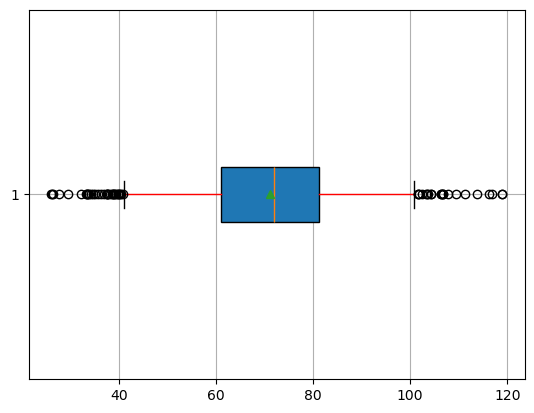

In [10]:
# plt.figure(figsize=(5,5))
plt.boxplot(data['Weight'],whis=True,vert=False,patch_artist=True,showmeans=True,whiskerprops={'color':"red"})
plt.grid()
plt.show()

In [11]:
np.percentile(data['Weight'],100)

np.float64(118.90736621037136)

In [12]:
s=pd.Series([1,2,3,2,1])
print(s.value_counts(normalize=True))

1    0.4
2    0.4
3    0.2
Name: proportion, dtype: float64
